# Isoelastic MNIST

Exploring the impact of using various loss functions on the performance of a simple neural network trained on the MNIST dataset. In particular, we will compare the standard cross-entropy loss with the [isoelastic loss](https://en.wikipedia.org/wiki/Isoelastic_utility) function:

$$
u_\gamma(c) = \frac{c^{1-\gamma} - 1}{1-\gamma}
$$

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Download and prepare the MNIST dataset

DATA_DIR = "./data"
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root=DATA_DIR,
    train=False,
    download=True,
    transform=transform
)

In [4]:
# Check the number of samples in the training and test datasets

print(len(train_dataset))
print(len(test_dataset))

60000
10000


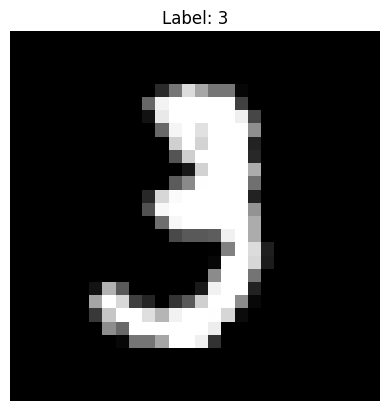

In [5]:
# Display a sample image and its label from the training dataset

image, label = train_dataset[10]

plt.imshow(image.squeeze(0), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

Simple code for counting the training examples in the MNIST dataset:

In [6]:
labels_train = list(set([label for _, label in train_dataset]))

label_counts_train = {label: 0 for label in labels_train}

In [7]:
for image, label in train_dataset:
    label_counts_train[label] += 1

print(label_counts_train)

{0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


In [ ]:
# A more compact implementation

#label_counts = {}

#for image, label in train_dataset:
#    label_counts[label] = label_counts.get(label, 0) + 1

#print(label_counts)

Simple code for counting the test examples in the MNIST dataset:

In [8]:
label_counts_test = {label: 0 for label in labels_train}

for image, label in test_dataset:
    label_counts_test[label] += 1

print(label_counts_test)

{0: 980, 1: 1135, 2: 1032, 3: 1010, 4: 982, 5: 892, 6: 958, 7: 1028, 8: 974, 9: 1009}


In [9]:
# Create data loaders for the training and test datasets

from torch.utils.data import DataLoader

In [10]:
# Define the batch size for training and testing

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# Check the shape of the tensor for the first image in the training dataset

train_dataset[0][0].shape

torch.Size([1, 28, 28])

## Construction of the Neural Network

In [13]:
# Determining the number of neurons in the input layer of a neural network for the MNIST dataset

n_initial = train_dataset[0][0].flatten().shape[0]
n_initial

784

Building a simple neural network (based on a [3Blue1Brown](https://www.youtube.com/watch?v=aircAruvnKk) tutorial)

In [77]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(n_initial, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=16, bias=True)
  (2): ReLU()
  (3): Linear(in_features=16, out_features=16, bias=True)
  (4): ReLU()
  (5): Linear(in_features=16, out_features=10, bias=True)
)


In the definition of the loss function we need to make a few implementation choices. We will keep the final layers to represent logits for the predicted class probabilities.

Therefore we will parform a softmax transformation to convert the logits in the loss function. In case of isoelastic utilities, the probabilities are not directly proportional to capital splitting ratios in a gamble. Therefore, we will need to perform a transformation to convert the predicted probabilities into capital splitting ratios.

If we play a double or nothing gamble, with $`n`$ possible outcomes, with $`p_i`$ chances, and we aim to maximize the expectation of an isoelastic utility function, we need to find the optimal capital splitting ratios $`p'_i`$ that maximize:

$$
p'_i = \frac{p_i^{1/\gamma}}{\sum_{j=1}^n p_j^{1/\gamma}}
$$

This can be done in one step from the logits ($`a_i`$) by applying the following transformation:

$$
p'_i = \frac{e^{a_i/\gamma}}{\sum_{j=1}^n e^{a_j/\gamma}}
$$

The loss function can then be defined as:

$$
L(\underline{a}, y) = -\sum_{i=1}^n \delta_{i,y} \cdot u_\gamma(p'_i(\underline{a}))
=
- u_\gamma\left(\frac{e^{a_y/\gamma}}{\sum_{j=1}^n e^{a_j/\gamma}}\right)
$$

Where $`y`$ is the true class label and $`\underline{a}`$ is the vector of logits predicted by the neural network.

In [61]:
import torch
import torch.nn as nn

class IsoelasticLoss(nn.Module):
    def __init__(self, gamma, max_power=1e6):
        super().__init__()
        self.gamma = gamma
        self.max_power = max_power

    def forward(self, logits, targets):
        # probs = torch.softmax(logits, dim=1)

        # Direct computation of capital splitting ratios (p') without computing probabilities
        portions = torch.softmax(logits / self.gamma, dim=1)
        pp = portions[torch.arange(targets.shape[0]), targets]

        pp = torch.clamp(pp, min=1e-8, max=1.0)

        if abs(self.gamma - 1.0) < 1e-8:
            return (-torch.log(pp)).mean()
        else:
            return ((1 - pp ** (1 - self.gamma)) / (1 - self.gamma)).mean()


Example for $`\gamma = 0.7`$:

In [62]:
gamma = 0.7
loss_fn = IsoelasticLoss(gamma=gamma)

In [63]:
images, labels = next(iter(train_loader))
logits = model(images)
loss = loss_fn(logits, labels)

print(logits.shape)
print(labels.shape)
print(loss.item())

torch.Size([64, 10])
torch.Size([64])
1.6438870429992676


In [78]:
# Set up the optimizer for training the model using stochastic gradient descent (SGD) with a learning rate of 0.01 and momentum of 0.9

import torch.optim as optim

gamma = 0.7
loss_fn = IsoelasticLoss(gamma=gamma)

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

In [79]:
# One training epoch

model.train()

total_loss = 0.0

for images, labels in train_loader:
    optimizer.zero_grad()
    
    probs = model(images)
    loss = loss_fn(probs, labels)
    
    loss.backward()
    optimizer.step()
    
    total_loss += loss.item()

print("Average training loss:", total_loss / len(train_loader))

Average training loss: 0.4973427027003216


In [80]:
# Train the model for multiple epochs and print the average training loss for each epoch

num_epochs = 2

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for images, labels in train_loader:
        optimizer.zero_grad()
        
        probs = model(images)
        loss = loss_fn(probs, labels)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}: average training loss = {avg_loss:.4f}")

Epoch 1: average training loss = 0.2008
Epoch 2: average training loss = 0.1723


### Evaluation of the trained model

To evaluate the performance of the trained model, we will compute the accuracy on the test set. The accuracy is defined as the proportion of correctly classified examples:

In [81]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images)
        predicted = logits.argmax(dim=1)
        
        total += labels.shape[0]
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

Test accuracy: 0.9321


Observing the output of the trained model for a few test examples:

In [82]:
print(model(test_dataset[0][0].unsqueeze(0)))

tensor([[-0.0353, -3.6558,  2.8304,  6.2213, -7.1225,  0.5595, -7.0994, 10.4276,
         -1.3191,  2.2541]], grad_fn=<AddmmBackward0>)


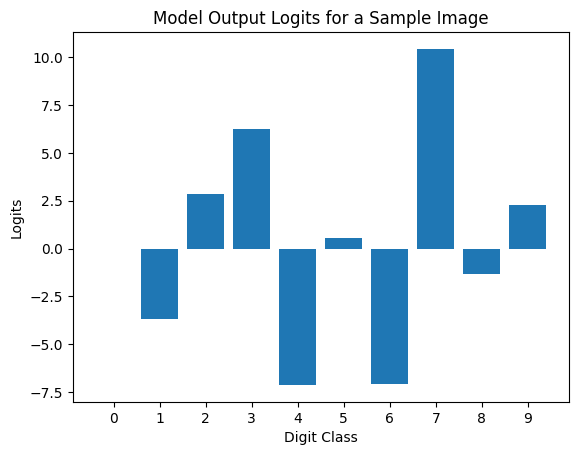

In [83]:
plt.bar(range(10), model(test_dataset[0][0].unsqueeze(0)).squeeze().detach().numpy())
plt.xlabel("Digit Class")
plt.ylabel("Logits")
plt.title("Model Output Logits for a Sample Image")
plt.xticks(range(10))
plt.show()

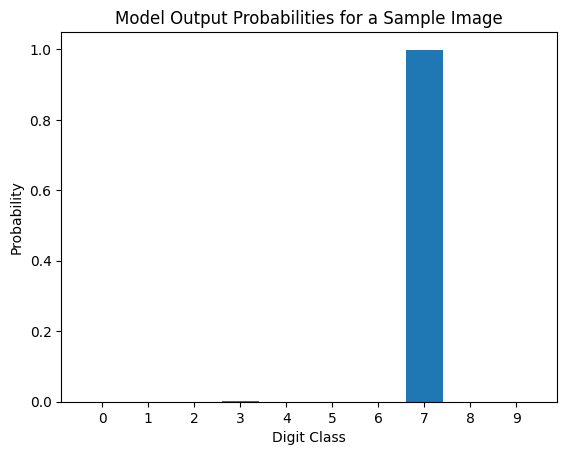

In [73]:
import torch
import torch.nn.functional as F

logits = model(test_dataset[0][0].unsqueeze(0)).squeeze().detach()
probs = F.softmax(logits, dim=0).numpy()

plt.bar(range(10), probs)
plt.xlabel("Digit Class")
plt.ylabel("Probability")
plt.title("Model Output Probabilities for a Sample Image")
plt.xticks(range(10))
plt.show()

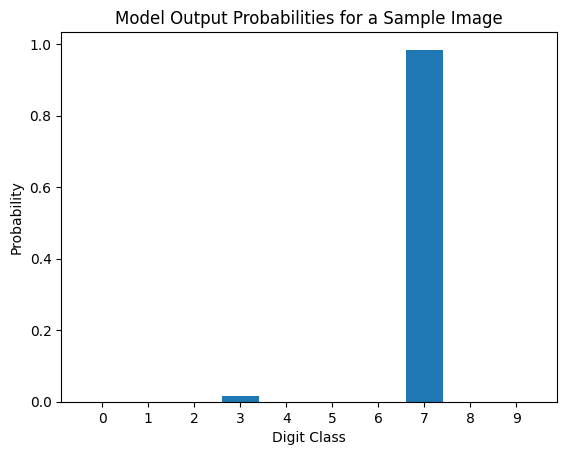

In [85]:
import torch
import torch.nn.functional as F

logits = model(test_dataset[0][0].unsqueeze(0)).squeeze().detach()
probs = F.softmax(logits, dim=0).numpy()

plt.bar(range(10), probs)
plt.xlabel("Digit Class")
plt.ylabel("Probability")
plt.title("Model Output Probabilities for a Sample Image")
plt.xticks(range(10))
plt.show()

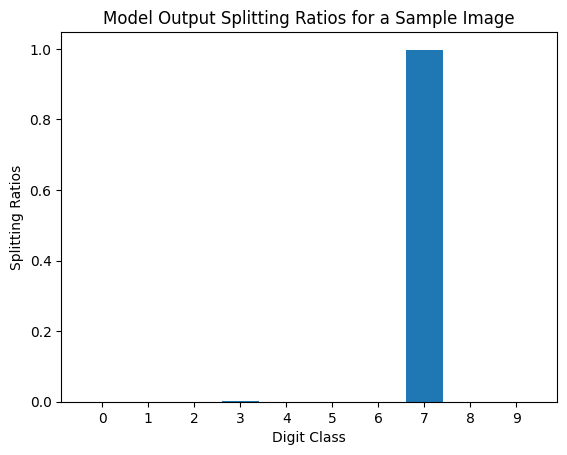

In [86]:
import torch
import torch.nn.functional as F

logits = model(test_dataset[0][0].unsqueeze(0)).squeeze().detach()
splitting_ratios = F.softmax(logits / gamma, dim=0).numpy()

plt.bar(range(10), splitting_ratios)
plt.xlabel("Digit Class")
plt.ylabel("Splitting Ratios")
plt.title("Model Output Splitting Ratios for a Sample Image")
plt.xticks(range(10))
plt.show()

## Running the experiment

gamma = 0.100, test accuracy = 0.6630
gamma = 0.200, test accuracy = 0.8450
gamma = 0.300, test accuracy = 0.9197
gamma = 0.400, test accuracy = 0.9296
gamma = 0.500, test accuracy = 0.9140
gamma = 0.600, test accuracy = 0.9188
gamma = 0.700, test accuracy = 0.9310
gamma = 0.800, test accuracy = 0.9361
gamma = 0.900, test accuracy = 0.9296
gamma = 1.000, test accuracy = 0.9307
gamma = 1.100, test accuracy = 0.9396
gamma = 1.200, test accuracy = 0.9289
gamma = 1.300, test accuracy = 0.9181
gamma = 1.400, test accuracy = 0.9154
gamma = 1.500, test accuracy = 0.4077
gamma = 1.600, test accuracy = 0.0982
gamma = 1.700, test accuracy = 0.1032
gamma = 1.800, test accuracy = 0.0982
gamma = 1.900, test accuracy = 0.1028


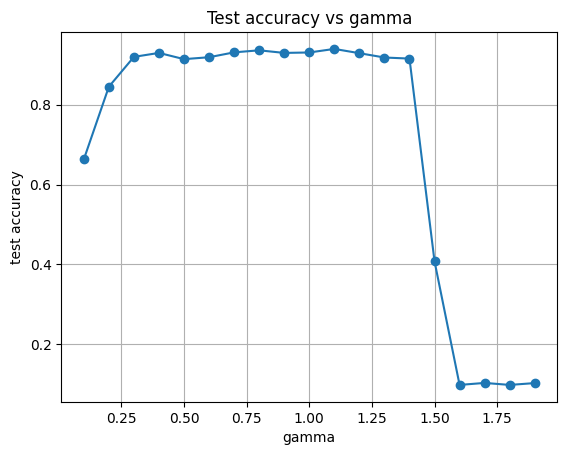

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

gammas = np.arange(0.1, 2.0, 0.1)
accuracies = []

num_epochs = 2

class IsoelasticLoss(nn.Module):
    def __init__(self, gamma, max_power=1e6):
        super().__init__()
        self.gamma = gamma
        self.max_power = max_power

    def forward(self, logits, targets):
        # probs = torch.softmax(logits, dim=1)
        portions = torch.softmax(logits / self.gamma, dim=1) # splitting_ratios
        pp = portions[torch.arange(targets.shape[0]), targets]

        pp = torch.clamp(pp, min=1e-8, max=1.0)

        if abs(self.gamma - 1.0) < 1e-8:
            return (-torch.log(pp)).mean()
        else:
            return ((1 - pp ** (1 - self.gamma)) / (1 - self.gamma)).mean()

for gamma in gammas:
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(n_initial, 16),
        nn.ReLU(),
        nn.Linear(16, 16),
        nn.ReLU(),
        nn.Linear(16, 10)
)

    loss_fn = IsoelasticLoss(gamma=gamma)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:
            optimizer.zero_grad()
            probs = model(images)
            loss = loss_fn(probs, labels)
            loss.backward()
            optimizer.step()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            probs = model(images)
            predicted = probs.argmax(dim=1)
            total += labels.shape[0]
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    accuracies.append(accuracy)

    print(f"gamma = {gamma:.3f}, test accuracy = {accuracy:.4f}")

plt.plot(gammas, accuracies, marker='o')
plt.xlabel("gamma")
plt.ylabel("test accuracy")
plt.title("Test accuracy vs gamma")
plt.grid(True)
plt.show()